In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
e0 = 8.854187817e-12  # Vacuum permittivity (F/m)
mu0 = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(e0 * mu0)

a = 1 # tamanho da reta (eixo x)
T = 10e-9 # tempo de simulação 

dx = 0.02
dt = 0.01e-9

nx = int(a / dx) + 1
nt = int(T / dt)

xgrid = np.linspace(0, a, nx)

# campos
Ey = np.zeros((nt, nx))
Hz = np.zeros((nt, nx-1))

# valor inicial do campo Ey em t = 0
Ey[0, :] = np.sin(np.pi / a * xgrid)

# marcha no tempo
for n in range(nt - 1):

    # atualiza o H
    Hz[n+1, :] = Hz[n, :] + (dt / (mu0 * dx)) * (Ey[n, 1:] - Ey[n, :-1])

    # atualiza o E
    Ey[n+1, 1:-1] = Ey[n, 1:-1] + (dt / (e0 * dx)) * (Hz[n+1, 1:] - Hz[n+1, :-1])

    # zero na condição de contorno (extremidades)
    Ey[n+1, 0] = 0
    Ey[n+1, -1] = 0



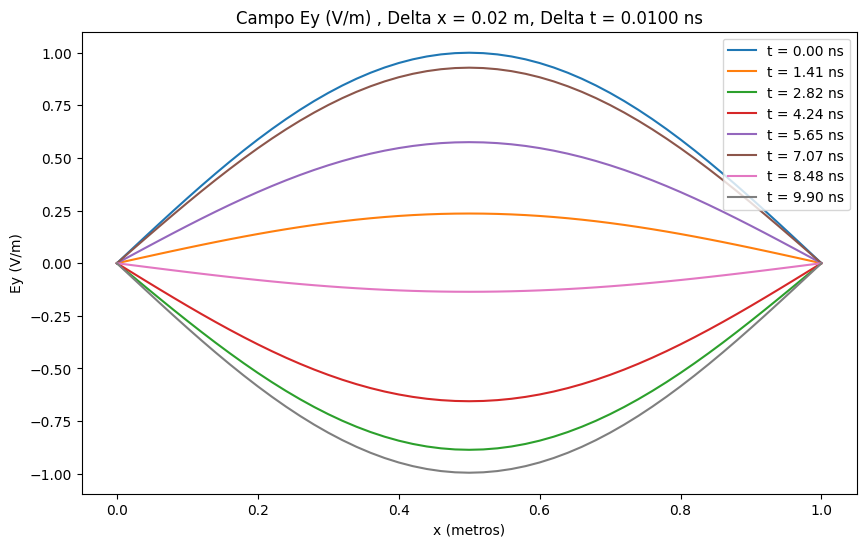

In [2]:
# Plot a few time snapshots
t_list = np.linspace(0, nt - 10, 8, dtype=int)
plt.figure(figsize=(10, 6))
for k in range(len(t_list)):
    plt.plot(xgrid, Ey[t_list[k], :], label=f"t = {t_list[k]*dt*1e9:.2f} ns")
plt.title(f"Campo Ey (V/m) , Delta x = {dx} m, Delta t = {dt*1e9:.4f} ns")
plt.xlabel("x (metros)")
plt.ylabel(f"Ey (V/m)")
plt.legend(loc='upper right')
plt.show()